<a href="https://colab.research.google.com/github/juanpablomgr/Proyecto-Pipeline-Business-Intelligence---Food-Delivery/blob/main/ProyectoIntegrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabajo Práctico Integrador: Pipeline ETL & Inteligencia de Mercado (Food Delivery)**

# Contexto de Negocio 🛵 📲 🍔
Usted ha sido contratado como Data Engineer y Analista BI por el CEO de una nueva startup de Food Delivery que busca expandirse en Estados Unidos. Antes de lanzar la aplicación y decidir en qué ciudades invertir, el directorio necesita entender cómo operan sus competidores actuales, qué categorías dominan el mercado y cómo se comportan los precios según la región.
El equipo de Web Scraping le ha entregado dos archivos crudos. Su misión es construir un pipeline ETL completo: extraer los datos, realizar una limpieza profunda (separar direcciones, traducir rangos de precios), optimizar el tamaño, cargarlos en un motor SQL local (SQLite) y, finalmente, responder a las preguntas críticas del CEO utilizando consultas SQL y gráficos profesionales.

📁💻 Archivo 1

Archivo: restaurants.csv

Descripción: Catálogo maestro de restaurantes. Contiene dirección completa concatenada, puntajes y rango de precios en símbolos ($)

Filas Aprox: 63,000

📁💻Archivo 2 (Separado en 10 partes)

Archivo: restaurant-menus.csv

Descripción: Detalle de cada ítem vendido. Contiene el nombre del plato y su precio en texto.

Filas Aprox: 5,000,000



📚 Importación de librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text


# **📥 Parte 1: Extracción y Diagnóstico de Datos**

1. Lectura del archivo "restaurants.csv"

In [5]:
#Se realiza la lectura del archivo restaurants.csv y se crea el dataframe "df_restaurantes"
df_restaurantes = pd.read_csv("restaurants.csv")

display(df_restaurantes)

,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,$,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700
...,...,...,...,...,...,...,...,...,...,...,...
63464,63465,2,IHOP (4321 N 10th St),4.6,56.0,"American, Breakfast and Brunch, burger, Comfor...",$,"4321 N 10th St, MC ALLEN, TX, 78504",78504,26.242853,-98.223984
63465,63466,29,Feldman's - N 10th Street,NaN,NaN,NaN,NaN,"3010 N 10th Street, Mc Allen, TX,",NaN,26.230764,-98.224922
63466,63467,27,Feldman's - N 23rd St,NaN,NaN,NaN,NaN,"6101 N 23rd Street #B, Mc Allen, TX,",NaN,26.260353,-98.236755
63467,63468,19,Church's Chicken (620 S. 10th Street),4.3,17.0,"Fast Food, Family Meals",$,"620 S. 10th Street, McAllen, TX, 78501",78501,26.197333,-98.231369


Análisis exploratorio de df_restaurantes

In [6]:
#Se aplica .shape para obtener las dimensiones del DataFrame

print(f'El DF df_restaurantes tiene {df_restaurantes.shape[0]} filas y {df_restaurantes.shape[1]} columnas')


El DF df_restaurantes tiene 63469 filas y 11 columnas


In [7]:
#Se aplica .dtypes para obtener los tipos de datos

df_restaurantes.dtypes

,0
id,int64
position,int64
name,object
score,float64
ratings,float64
category,object
price_range,object
full_address,object
zip_code,object
lat,float64


In [8]:
#Se aplica isnull para obtener la cantidad de valores nulos

df_restaurantes.isnull().sum()

,0
id,0
position,0
name,0
score,28167
ratings,28167
category,85
price_range,10617
full_address,453
zip_code,517
lat,0


2. Lectura de los archivos restaurant_menus_parte_##.csv

Ya que el archivo restaurant_menus se encuentra dividido en 10 partes, se realiza la creación de un bucle para poder leer todos los archivos y consolidarlos en un solo DataFrame.

In [9]:
#Creación de lista con los nombres del archivo usando una list comprehension

menus_parte =  [f"restaurant_menus_parte_{nro}.csv" for nro in range(1,11)]
display(menus_parte)

['restaurant_menus_parte_1.csv',
 'restaurant_menus_parte_2.csv',
 'restaurant_menus_parte_3.csv',
 'restaurant_menus_parte_4.csv',
 'restaurant_menus_parte_5.csv',
 'restaurant_menus_parte_6.csv',
 'restaurant_menus_parte_7.csv',
 'restaurant_menus_parte_8.csv',
 'restaurant_menus_parte_9.csv',
 'restaurant_menus_parte_10.csv']

In [10]:
#Creación de lista vacia para guardar los dataframe de cada parte, una a una.
lista_dfs = []

#Creación de bucle para la lectura de los archivos "restaurant_menus_parte_x" y
#consolidando todo en un solo DataFrame

for menus in menus_parte:
  lista_dfs.append(pd.read_csv(menus))
  print(f" {menus}: {len(pd.read_csv(menus))} filas")

# Creamos el df_menus y usamos Concat para unir todos los dataframes en uno solo
# Se utiliza el parámetro ignore_index = True para resetear el indice y evitar repetir numeros de fila

df_menus = pd.concat(lista_dfs, ignore_index = True)


 restaurant_menus_parte_1.csv: 83635 filas
 restaurant_menus_parte_2.csv: 83635 filas
 restaurant_menus_parte_3.csv: 83635 filas
 restaurant_menus_parte_4.csv: 83635 filas
 restaurant_menus_parte_5.csv: 83635 filas
 restaurant_menus_parte_6.csv: 83635 filas
 restaurant_menus_parte_7.csv: 83635 filas
 restaurant_menus_parte_8.csv: 83635 filas
 restaurant_menus_parte_9.csv: 83635 filas
 restaurant_menus_parte_10.csv: 83635 filas


Análisis exploratorio

In [11]:
#Se aplica .shape para determinar sus dimensiones
print(f"El DataFrame df_menus tiene {df_menus.shape[0]} columnas y {df_menus.shape[1]} filas")

El DataFrame df_menus tiene 836350 columnas y 5 filas


In [12]:
#Se utiliza .dtypes para determinar los tipos de datos
df_menus.dtypes

,0
restaurant_id,int64
category,object
name,object
description,object
price,object


In [13]:
# Se determina la cantidad de valores nulos mediante .isnull().sum()
df_menus.isnull().sum()

,0
restaurant_id,0
category,0
name,1
description,200324
price,0


In [14]:
df_menus.head()

,restaurant_id,category,name,description,price
0,1,Extra Large Pizza,Extra Large Meat Lovers,Whole pie.,15.99 USD
1,1,Extra Large Pizza,Extra Large Supreme,Whole pie.,15.99 USD
2,1,Extra Large Pizza,Extra Large Pepperoni,Whole pie.,14.99 USD
3,1,Extra Large Pizza,Extra Large BBQ Chicken &amp; Bacon,Whole Pie,15.99 USD
4,1,Extra Large Pizza,Extra Large 5 Cheese,Whole pie.,14.99 USD


# **📥 Parte 2: Ingeniería de Características y Limpieza (Transform)**


**En df_ restaurantes**

In [15]:
df_restaurantes.head()

,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,$,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700


# 💵 **1. Mapeo de Precios:**

La columna rango_de_precios contiene símbolos ($, $$,
etc.). Utilice un diccionario y la función .map() o .replace() para transformarlos a
texto legible:

In [16]:
# $ -> "Económico"
# $$ -> "Moderadamente caro"
# $$$ -> "Caro"
# $$$$ -> "Muy caro"

Analizamos la cantidad de los valores únicos de la columna price_range incluyendo a los valores null con la función .value_counts(dropna = False)

In [17]:

df_restaurantes['price_range'].value_counts(dropna=False)

,count
price_range,
$,37637
$$,14952
NaN,10617
$$$,237
$$$$,25
$$$$$$$$$$$$$$$$$,1


Se determinó que existe un valor que no corresponde a ningun rango específico en la columna price_range.
Se procede a limpiar el valor corrupto que contiene más de 4 símbolos "$"

Se utiliza la función .map() para poder mapear los valores no reconocidos y que se transformen a NaN

In [18]:
mapa_precios = { "$" : "Económico" ,
                "$$" :"Moderadamente caro",
                "$$$" : "Caro",
                "$$$$" : "Muy caro" }

In [19]:
df_restaurantes['price_range'] = df_restaurantes['price_range'].map(mapa_precios)

Verificamos el resultado


In [20]:
df_restaurantes['price_range'].value_counts(dropna=False)

,count
price_range,
Económico,37637
Moderadamente caro,14952
NaN,10618
Caro,237
Muy caro,25


# 📍**2. Desanidado de Ubicaciones (Split):**

La columna dirección_completa contiene
la calle, ciudad, estado y código postal separados por comas.

Utilice el método
.str.split(',', expand=True) para crear tres nuevas columnas: calle, ciudad y
estado_zip. Asegúrese de aplicar .str.strip() a la nueva columna ciudad para
quitar espacios ocultos.

In [21]:
df_restaurantes['full_address']

,full_address
0,"224 Daniel Payne Drive, Birmingham, AL, 35207"
1,"1521 Pinson Valley Parkway, Birmingham, AL, 35217"
2,"541-B Graymont Ave, Birmingham, AL, 35204"
3,"1580 Montgomery Highway, Hoover, AL, 35226"
4,"314 17th St N, Birmingham, AL, 35203"
...,...
63464,"4321 N 10th St, MC ALLEN, TX, 78504"
63465,"3010 N 10th Street, Mc Allen, TX,"
63466,"6101 N 23rd Street #B, Mc Allen, TX,"
63467,"620 S. 10th Street, McAllen, TX, 78501"


In [22]:
# Separación de la columna en df_restaurantes ['full_address']

# ".str.split(,)" divide por comas
# "expand = True" convierte el resultado en columnas separadas

df_split_restaurantes = df_restaurantes['full_address'].str.strip().str.split(',', expand=True)


In [23]:
df_split_restaurantes

,0,1,2,3,4,5,6,7,8,9,10,11
0,224 Daniel Payne Drive,Birmingham,AL,35207,None,None,None,None,None,None,None,None
1,1521 Pinson Valley Parkway,Birmingham,AL,35217,None,None,None,None,None,None,None,None
2,541-B Graymont Ave,Birmingham,AL,35204,None,None,None,None,None,None,None,None
3,1580 Montgomery Highway,Hoover,AL,35226,None,None,None,None,None,None,None,None
4,314 17th St N,Birmingham,AL,35203,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
63464,4321 N 10th St,MC ALLEN,TX,78504,None,None,None,None,None,None,None,None
63465,3010 N 10th Street,Mc Allen,TX,,None,None,None,None,None,None,None,None
63466,6101 N 23rd Street #B,Mc Allen,TX,,None,None,None,None,None,None,None,None
63467,620 S. 10th Street,McAllen,TX,78501,None,None,None,None,None,None,None,None


In [24]:
# Definición de funciones para extraer cada parte de la dirección:

# Creación de una función para extraer la calle de "df_split_restaurantes"

def extraer_calle(fila):
  valores = fila.dropna().tolist()  # No incluye valores "None" y los convierte a lista
  if len(valores) >=1:              # Se necesita al menos 1 elemento
    return valores [0]              # La calle está en el elemento de orden [0]
  return None

In [25]:
# Creación de una función para extraer la ciudad de "df_split_restaurantes"

def extraer_ciudad(fila):
  valores = fila.dropna().tolist()    # No incluye valores "None" y los convierte a lista
  if len(valores) >= 3:               # Se necesita al menos 3 elementos
    return valores [-3]               # La ciudad está en el elemento de orden [-3], es decir es el tercer elemento contado desde el final
  return None


In [26]:
# Creación de una función para extraer el estado y el zip code de "df_split_restaurantes"

def extraer_estado_zip (fila):
  valores = fila.dropna().tolist()    # No incluye valores "None" y los convierte a lista
  if len(valores) >= 2:               # Se necesita al menos 2 elementos
    return valores [-2]               # El estado y zip code están en el elemento de orden [-2], es decir es el segundo elemento contado desde el final
  return None

In [27]:
# Aplicando funciones y creando columnas nuevas

#apply(funcion, axis = 1) : ejecuta la funcion fila por fila (axis = 1)
#str.strip() : elimina espacios en blanco en los bordes

df_restaurantes['calle'] = df_split_restaurantes.apply(extraer_calle, axis=1).str.strip()
df_restaurantes ['ciudad'] = df_split_restaurantes.apply(extraer_ciudad, axis=1).str.strip()
df_restaurantes ['estado_zip'] = df_split_restaurantes.apply(extraer_estado_zip, axis=1).str.strip()

In [28]:
#Comprobación de nulos en ciudad

print("Nulos en full_adress: ", df_restaurantes['full_address'].isnull().sum())

print("Nulos en ciudad: ", df_restaurantes['ciudad'].isnull().sum())

print("Nulos en estado_zip: ", df_restaurantes['estado_zip'].isnull().sum())

print("Nulos en calle: ", df_restaurantes['calle'].isnull().sum())

Nulos en full_adress:  453
Nulos en ciudad:  453
Nulos en estado_zip:  453
Nulos en calle:  453


# ᯤ 3. Filtro de Calidad:
Elimine los restaurantes que no tengan puntaje (score nulo) o cuyo puntaje sea 0. Estandarice la columna category a minúsculas.
En df_

In [29]:
# Número de filas previo filtrado
nro_filas_antes_filtro = len(df_restaurantes)
nro_filas_antes_filtro

63469

In [30]:
# Filtro, incluyendo solo a valores que no sean nulos y cuyo score sea mayor a 0, por tanto
# excluyendo a valores nulos y cuyo score sea 0
df_restaurantes = df_restaurantes [ df_restaurantes['score'].notnull() &
                                          (df_restaurantes['score'] > 0 )]

In [31]:
# Número de filas post filtrado
nro_filas_despues_filtro = len(df_restaurantes)
display(nro_filas_despues_filtro)

35302

In [32]:
# Estandarizando columna "category" a columnas

df_restaurantes['category'] = df_restaurantes['category'].str.lower()
display(df_restaurantes['category'])

,category
4,"breakfast and brunch, burgers, sandwiches"
6,"sushi, asian, japanese"
13,"breakfast and brunch, salad, sandwich, family ..."
15,"ice cream &amp; frozen yogurt, comfort food, d..."
18,"middle eastern, mediterranean, vegetarian, gre..."
...,...
63448,"pharmacy, convenience, everyday essentials, baby"
63460,"american, bar food, wings, fast food, chicken,..."
63462,"burgers, fast food, burgers, sandwiches, american"
63464,"american, breakfast and brunch, burger, comfor..."


**En df_menus**

1. La columna price viene como texto (ej. "15,99 USD"). Cree una función lambda o use .str.replace() para eliminar el texto " USD", reemplazar la coma por un punto, y castear el resultado a formato decimal (float).

In [33]:
print("ANTES:")
print(df_menus['price'].tail(5).tolist())

ANTES:
['4.99 USD', '2.98 USD', '7.19 USD', '4.01 USD', '3.8']


In [34]:
# Eliminado el texto "USD"  y también reemplazando la coma por punto utilizando .str.replace()
# Casteo del resultado a formato decimal con astype(float)

df_menus['price'] = df_menus['price'].str.replace('USD','').str.replace(',','.').astype(float)

In [35]:
display(df_menus['price'])

,price
0,15.99
1,15.99
2,14.99
3,15.99
4,14.99
...,...
836345,4.99
836346,2.98
836347,7.19
836348,4.01


2. Elimine los ítems del menú con precio igual a 0.0 o nulos

In [36]:
# Número de filas previo filtrado

filas_antes_filtro_precio = len(df_menus)
filas_antes_filtro_precio

836350

In [37]:
# Filtrado de items con precio = 0 o NULL

df_menus = df_menus[df_menus['price'].notnull()
                    & (df_menus['price'] > 0)]

In [38]:
# Número de filas post filtrado
filas_despues_filtro_precio = len(df_menus)
filas_despues_filtro_precio

798797

# **🔀 Optimización y Cruce (Control de Memoria RAM):**

Realice un inner join (pd.merge) entre su df_restaurantes y df_menus utilizando el ID del restaurante.

Guardar el cruce en un DataFrame llamado df_master

In [39]:
# Inner Join entre df_restaurantes y df_menus, guardando resultado en df_master

df_master = pd.merge(df_restaurantes, df_menus,
                     left_on = 'id', right_on = 'restaurant_id',
                     how = 'inner')

In [40]:
# Comprobando resultado

df_master.head()

,id,position,name_x,score,ratings,category_x,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,restaurant_id,category_y,name_y,description,price
0,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,5,Picked for you,Pork Chop Rice with Gravy Plate,NaN,7.00
1,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,5,Picked for you,Full Sausage (2 pcs) with 2 Eggs,2 pieces.,7.25
2,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,5,Picked for you,Bacon and Egg with Cheese Breakfast Sandwich,NaN,3.50
3,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,5,Picked for you,Double Cheese Burger,Grilled or fried patty with cheese on a bun.,3.25
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,5,Picked for you,Full Bacon (3 pcs) with 2 Eggs,3 pieces.,7.25


In [41]:
# Se observa que hay una columna duplicada producto del INNER JOIN
# Se procede a eliminarla

df_master = df_master.drop(columns = 'restaurant_id')

In [42]:
df_master.head()

,id,position,name_x,score,ratings,category_x,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,category_y,name_y,description,price
0,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,Picked for you,Pork Chop Rice with Gravy Plate,NaN,7.00
1,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,Picked for you,Full Sausage (2 pcs) with 2 Eggs,2 pieces.,7.25
2,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,Picked for you,Bacon and Egg with Cheese Breakfast Sandwich,NaN,3.50
3,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,Picked for you,Double Cheese Burger,Grilled or fried patty with cheese on a bun.,3.25
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,Picked for you,Full Bacon (3 pcs) with 2 Eggs,3 pieces.,7.25


## 📤 **Parte 3 - Carga a Base de Datos (Load)**


1. Importe la librería sqlalchemy y genere un motor (create_engine) para una base de datos SQLite local llamada delivery_insights.db.
2. Utilice df_master.to_sql() para cargar su tabla final a la base de datos con el nombre master_food_data. Use if_exists="replace" y index=False.

In [43]:
# Importando libreria sqlalchemy y generando un motor "create_engine"
from sqlalchemy import create_engine

In [44]:
# Base de datos local: delivery_insights.db
motor_sql = create_engine('sqlite:///delivery_insights.db')

In [45]:
#Cargando df_master a master_food_data
df_master.to_sql(name = 'master_food_data',
                 con = motor_sql,
                 if_exists = 'replace',
                 index = False)

387350

# **🧠 📈 Parte 4 - Business Intelligence: Reporte al CEO (SQL + Visualización)**

Conéctese a su base de datos SQLite mediante pd.read_sql(text(query), conn). Por cada pregunta, presente el Query ejecutado, el DataFrame resultante y un gráfico explicativo de alto nivel.

In [46]:
#Definiendo una query de prueba para conectarnos a la base de datos SQLITE
query = """
SELECT count(*) as [Nro_Registros]
FROM master_food_data
"""

In [47]:
# Conectando a la base de datos SQLite y con la variable definida anteriormente "query"

with motor_sql.connect() as conexion:
  query_output = pd.read_sql(text(query), conexion)

In [48]:
# Resultados del query
print(query_output)

   Nro_Registros
0         387350


# **🌏 Penetración Geográfica:**

📌 ¿Cuáles son las 5 ciudades con la mayor cantidad de restaurantes consolidados (los que quedaron en nuestra base)?

Gráfico sugerido:
Gráfico de barras horizontal ordenado de mayor a menor.

In [49]:
df_master.head(1)

,id,position,name_x,score,ratings,category_x,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,category_y,name_y,description,price
0,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"breakfast and brunch, burgers, sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.51473,-86.8117,314 17th St N,Birmingham,AL,Picked for you,Pork Chop Rice with Gravy Plate,NaN,7.0


In [50]:
# Para hallar las ciudades con la mayor cantidad de restaurantes usamos la siguiente query,
# obteniendo el resultado:

query1 = """

    SELECT
        ciudad,
        COUNT(DISTINCT id) AS nro_restaurantes
    FROM master_food_data
    GROUP BY ciudad
    ORDER BY nro_restaurantes DESC
    LIMIT 5

"""
with motor_sql.connect() as conexion:
    query_output1 = pd.read_sql(text(query1), conexion)

print(query_output1)

      ciudad  nro_restaurantes
0    Seattle               388
1  Milwaukee               353
2    Madison               241
3   Bellevue               150
4   Lynnwood               126


In [51]:
# Importamos la libreria matplotlib y numpy

import matplotlib.pyplot as plt
import numpy as np

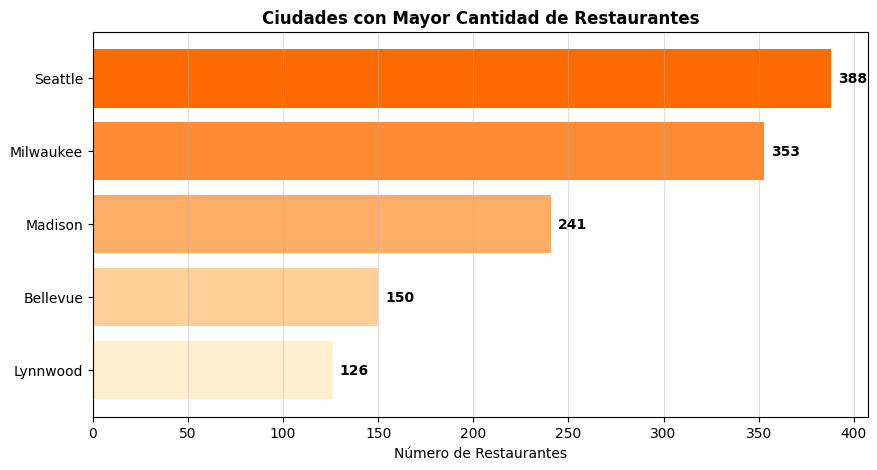

In [133]:
# Gráfico de barras usando matplotlib

plt.figure(figsize=(10, 5))          # Tamaño del lienzo de la gráfica

colores = ['#FF6B00', '#FF8C33', '#FFAD66', '#FFCE99', '#FFEFCC']
barra = plt.barh(query_output1['ciudad'], query_output1['nro_restaurantes'], color = colores)
plt.title('Ciudades con Mayor Cantidad de Restaurantes', fontweight = 'bold')
plt.xlabel('Número de Restaurantes')
plt.bar_label(barra, padding = 5, fontweight = 'bold')    #Añadimos el valor para cada ciudad con una separación adecuada
plt.grid(axis='x', alpha=0.4)
plt.gca().invert_yaxis()             #Invertimos el eje para tener orden de mayor a menor
plt.show()


🧠 Insight:

Los mercados con mayor presencia de restaurantes se sitúan en las ciudades de Seattle y Milwaukee.

# **🏷️🧐 Análisis de Oportunidad de Precio:**


El CEO cree que todos los restaurantes en el mercado son caros. Usando los datos, muestre la distribución de la columna rango_de_precios a nivel general

📌¿Cuántos hay en "Económico", "Caro", etc.?

Gráfico sugerido: Gráfico de torta (Pie chart) o Donut chart.

In [53]:
df_master.tail(1)

,id,position,name_x,score,ratings,category_x,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,category_y,name_y,description,price
387349,10082,4,McDonald's® (Camas),4.6,99.0,"american, fast food, burgers",Económico,"3354 NE 3rd Ave, Camas, WA, 98607",98607,45.584572,-122.3699,3354 NE 3rd Ave,Camas,WA,Individual Items,4 Piece McNuggets,NaN,3.8


In [54]:
# Para hallar la distribución de rango de precios a nivel general usamos la siguiente query,
# obteniendo el resultado:

query2 = """

    SELECT
        price_range as rango_precios,
        COUNT(DISTINCT id) AS cantidad
    FROM master_food_data
    WHERE price_range IS NOT NULL
    GROUP BY price_range
    ORDER BY cantidad DESC
"""
with motor_sql.connect() as conexion:
    query_output2 = pd.read_sql(text(query2), conexion)

print(query_output2)

        rango_precios  cantidad
0           Económico      2867
1  Moderadamente caro       924
2                Caro        17
3            Muy caro         1


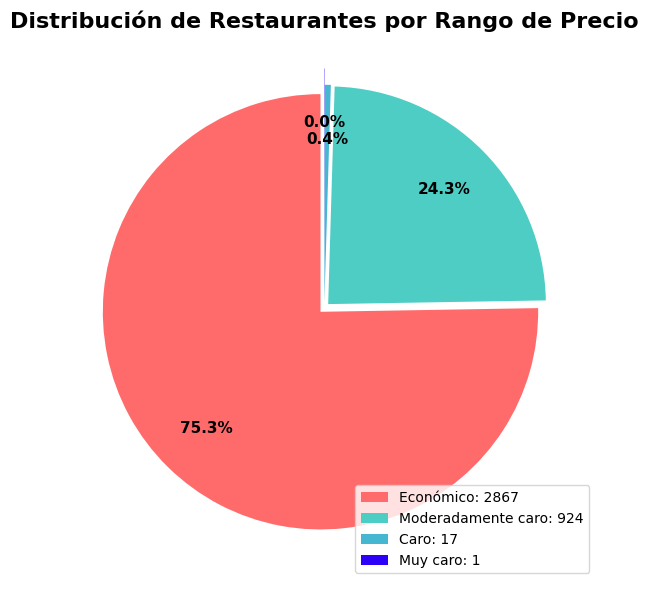

In [132]:
# Gráfico de pie
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#2D00F7']

leyenda = query_output2['rango_precios'] + ': ' + query_output2['cantidad'].astype(str)
plt.figure(figsize=(6,6))

plt.pie(
    query_output2['cantidad'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=.75,        # aleja los porcentajes del centro
    explode=(0.025, 0.025, 0.025, 0.1),      # aleja las etiquetas del borde
    colors=colores,
    textprops=dict(fontsize=11, fontweight='bold')
    )

plt.legend(leyenda, loc='lower right')
plt.title("Distribución de Restaurantes por Rango de Precio", fontweight = 'bold', fontsize=16)
plt.tight_layout()
plt.show()

🧠 Insight:

Hay una predominancia del sector económico en el mercado con un 75.3% de presencia. El segundo segmento seria el de restaurantes moderadamente caros con un 24.3%. El segmento "caro" y "muy caro" no son representativos.

# **🍽️📍Estrategia de Menú por Ciudad:**

Para las 3 ciudades más populares obtenidas en la pregunta 1, calcule el precio promedio de los platos en el menú.

📌 ¿En qué ciudad es más caro comer en promedio?

Gráfico sugerido: Gráfico de barras comparativo.

In [56]:
# Para hallar la distribución de rango de precios a nivel general usamos la siguiente query,
# obteniendo el resultado:

query3 = """
  SELECT
    ciudad,
    ROUND(AVG(price), 2) as precio_prom
  FROM master_food_data
  WHERE ciudad IN (
      SELECT ciudad
      FROM master_food_data
      GROUP BY ciudad
      ORDER BY count(distinct id) DESC
      LIMIT 3
      )
  GROUP BY ciudad
  ORDER by precio_prom DESC
"""
with motor_sql.connect() as conexion:
    query_output3 = pd.read_sql(text(query3), conexion)

print(query_output3)

      ciudad  precio_prom
0    Seattle        12.05
1  Milwaukee        10.12
2    Madison        10.05


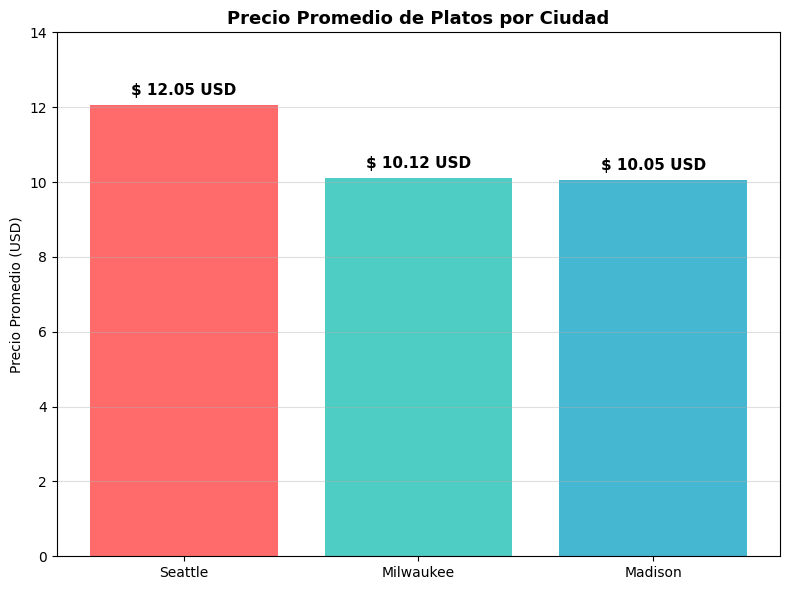

In [112]:
# Gráfico de barras comparativo
plt.figure(figsize=(8, 6))

colores = ['#FF6B6B', '#4ECDC4', '#45B7D1']

barra2 = plt.bar(query_output3['ciudad'], query_output3['precio_prom'], color=colores)

plt.bar_label(barra2,
              fmt='%.2f USD',
              padding=5,
              fontweight='bold',
              fontsize=11)

plt.title('Precio Promedio de Platos por Ciudad', fontweight='bold', fontsize=13)
plt.ylabel('Precio Promedio (USD)')
plt.ylim(0, 14)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

🧠 Insight:

* Seattle no solo lidera en cantidad de restaurante sino que además es el líder en precio promedio, esto significa que es el sector con mayor disposición a pagar y tolerancia al precio.


# **📈 💵 La Pregunta del Millón (Correlación Precio-Calidad):**


 📌¿Un restaurante más caro garantiza una mejor experiencia para el usuario?

 Escriba un query que calcule el puntaje (score) promedio agrupado por rango_de_precios.


 Utilice un gráfico de líneas o de barras para demostrar visualmente al CEO si la calidad sube a medida que aumenta la categoría de precio

In [58]:
# Para hallar la distribución de rango de precios a nivel general usamos la siguiente query,
# obteniendo el resultado:

query4 = """
    SELECT
        price_range,
        ROUND(AVG(score), 2) as prom_score
    FROM master_food_data
    WHERE price_range IS NOT NULL
    GROUP BY price_range
    ORDER BY
        CASE price_range
            WHEN 'Económico'          THEN 1
            WHEN 'Moderadamente caro' THEN 2
            WHEN 'Caro'               THEN 3
            WHEN 'Muy caro'           THEN 4
        END
"""
with motor_sql.connect() as conexion:
    query_output4 = pd.read_sql(text(query4), conexion)

print(query_output4)

          price_range  prom_score
0           Económico        4.54
1  Moderadamente caro        4.51
2                Caro        4.55
3            Muy caro        4.80


**Coeficiente de Correlación:**

Cuantifica la fuerza y dirección de la relación lineal entre dos variables. Sus valores oscilan entre "-1" a "1"

* Correlación de (1): Relación positiva perfecta. Ambas variables aumentan en la misma proporción.
* Correlación de (-1): Relación negativa perfecta. Al aumentar una variable, la otra disminuye.
* Correlación de (0): No existe relación lineal entre las variables.
* Valores intermedios: Mientras más cerca esté el valor de (1) o (-1), más fuerte es la relación lineal; mientras más cerca esté de (0), es más débil.

In [59]:
# Generando un diccionario que relaciona a cada categoría con un valor representativo.
# Se realiza esto ya que para hallar la correlación necesitamos dos variables numéricas

categoria_valor = {
    'Económico':          1,
    'Moderadamente caro': 2,
    'Caro':               3,
    'Muy caro':           4
}

#Creación de nueva columna "precio_numerico"  y reemplazo a partir de "price_range" y con la condiciones de "categoria_valor"
query_output4['precio_numerico'] = query_output4['price_range'].map(categoria_valor)


Correlación precio-calidad: 0.79


In [61]:
print(query_output4)

          price_range  prom_score  precio_numerico
0           Económico        4.54                1
1  Moderadamente caro        4.51                2
2                Caro        4.55                3
3            Muy caro        4.80                4


In [62]:
#Cálculo de la correlación con .corr() entre dos columnas numéricas - precio_numerico y prom_score
correlacion = query_output4['precio_numerico'].corr(query_output4['prom_score'])

print(f"Correlación precio-calidad: {round(correlacion, 2)}")

Correlación precio-calidad: 0.79


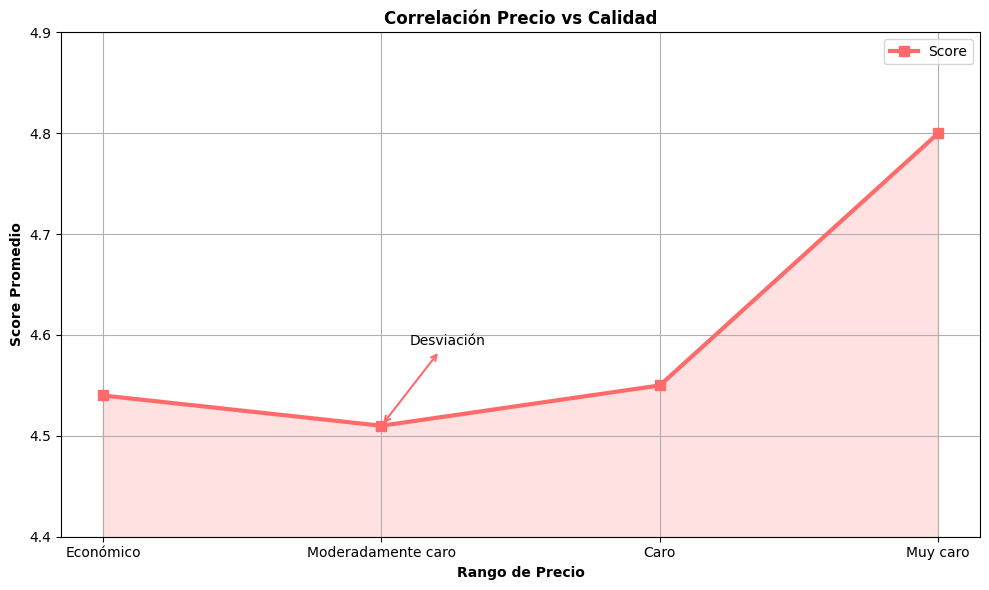

In [141]:
#Gráfico de Lineas

plt.figure(figsize=(10,6))
plt.plot(
    query_output4['price_range'],
    query_output4['prom_score'],
    marker='s',
    color='#FF6B6B',
    linewidth=3,
    markersize=6.5,
    label = 'Score')

plt.annotate('Desviación',
                  xy = (1,4.51), # señalar el punto en la grafica
                  xytext = (1.1,4.59),  #señalar la posicion del texto
                  arrowprops = dict(
                      color = '#FF6B6B',   #color flecha
                      arrowstyle = '<->',#estilo de flecha
                      linewidth = 1.5,
                      ))
plt.ylabel("Score Promedio", fontweight = 'bold')
plt.xlabel("Rango de Precio", fontweight = 'bold')
plt.title("Correlación Precio vs Calidad", fontweight = 'bold')
plt.ylim(4.4, 4.9)
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.fill_between(
    query_output4['price_range'],
    query_output4['prom_score'],
    alpha=0.2,
    color='#FF6B6B')
plt.show()

🧠 Insight:

* El coeficiente de correlación obtenido fue de 0.79, esto indica una correlación positiva fuerte entre precio y calidad mas no absoluta.

* Analizando las tendencias se denota que generalmente los restaurantes más caros tienen mejor score, pero esto no es una regla absoluta. Los restaurantes económicos superan en score a los moderadamente caros.
Por lo tanto, podemos determinar que el precio no necesariamente garantiza una mejor experiencia.

* Esto a líneas generales representa una oportunidad para el negocio al existir la posibilidad de competir con calidad sin necesidad de posicionarse como la opción más lujosa del mercado
